In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

In [28]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu (File đã có sẵn Lags, MA, Tech và Research features)
file_path = "D:/DataMining/sgu-2026-datamining-timeseries/Data/btc_base.csv"
df_raw = pd.read_csv(file_path, parse_dates=True, index_col=0)

# 2. Chuẩn hóa tên cột (đưa về chữ thường hết để tránh nhầm lẫn Volume/volume)
df_raw.columns = [c.lower() for c in df_raw.columns]

# 3. Loại bỏ các cột trùng lặp và sắp xếp theo thời gian
df = df_raw.loc[:, ~df_raw.columns.duplicated()].copy()
df = df[~df.index.duplicated(keep='last')].sort_index()

# 4. Đảm bảo có cột 'price'
if 'close' in df.columns and 'price' not in df.columns:
    df = df.rename(columns={'close': 'price'})

# 5. Tính toán log_return (đảm bảo tính chính xác)
df['log_return'] = np.log(df['price'] / df['price'].shift(1))
df = df.dropna()

# 6. Gán cho df_features để tiếp tục Train
df_features = df.copy()

print(f"✅ Thành công! Dữ liệu đã sạch. Tổng số cột: {len(df_features.columns)}")
display(df_features.head())

def create_features(df_slice, is_train=False):
    # Vì file CSV btc_base_plus_volatility đã có sẵn toàn bộ đặc trưng, 
    # chúng ta chỉ cần trả về dữ liệu mà không cần tính toán lại.
    return df_slice

✅ Thành công! Dữ liệu đã sạch. Tổng số cột: 12


,price,volume,log_return,hour,day_of_week,return_lag_1h,return_lag_12h,return_lag_24h,return_lag_168h,momentum_24h,rsi,target_log_return
Date,,,,,,,,,,,,
2024-10-08 02:00:00,62785.78,790.25190,0.002484,2,1,0.001231,0.008388,-0.002851,-0.000224,-0.013381,49.121328,-0.002487
2024-10-08 03:00:00,62629.80,473.99204,-0.002487,3,1,0.002484,-0.005332,-0.001679,0.004399,-0.014178,41.938733,0.001039
2024-10-08 04:00:00,62694.90,567.31828,0.001039,4,1,-0.002487,0.002641,-0.001006,0.002280,-0.012160,36.094272,-0.002836
2024-10-08 05:00:00,62517.35,719.31657,-0.002836,5,1,0.001039,0.000001,-0.001366,-0.001864,-0.013611,37.399378,-0.000127
2024-10-08 06:00:00,62509.42,580.02424,-0.000127,6,1,-0.002836,-0.015347,0.005130,0.004445,-0.018783,34.903696,-0.003035


In [29]:
val_size = int(len(df_features) * 0.15)
test_size = int(len(df_features) * 0.15)

window_size = 1500  
train_end_idx = len(df_features) - val_size - test_size
train_start_idx = max(0, train_end_idx - window_size)
train_size = train_end_idx - train_start_idx

# Cắt lớp từng khúc (Tập Train lấy theo Sliding Window gần nhất)
train_df = df_features.iloc[train_start_idx : train_end_idx]
val_df   = df_features.iloc[train_end_idx : train_end_idx+val_size]
test_df  = df_features.iloc[train_end_idx+val_size :]

# X là Features (Lịch Sử Trễ, KHÔNG chứa Cả price và target_log_return)
# y là Mục Tiêu MỚI: target_log_return (Log Returns: ln(P_t / P_t-1))
drop_cols = ['price', 'target_log_return']

X_train = train_df.drop(drop_cols, axis=1)
y_train = train_df['target_log_return']

X_val = val_df.drop(drop_cols, axis=1)
y_val = val_df['target_log_return']

X_test = test_df.drop(drop_cols, axis=1)
y_test = test_df['target_log_return']

# Lưu lại price chuẩn để Inverse (Khôi phục Price khi dự báo)
price_val = val_df['price']
price_test = test_df['price']

print(f"XGBoost sẽ học TRÊN CỬA SỔ TRƯỢT với {len(X_train)} giờ gần nhất (Slide Window)")
print(f"Kiểm tra tinh chỉnh bằng {len(X_val)} giờ | Và thi thật trên {len(X_test)} giờ Tương Lai")

XGBoost sẽ học TRÊN CỬA SỔ TRƯỢT với 1500 giờ gần nhất (Slide Window)
Kiểm tra tinh chỉnh bằng 796 giờ | Và thi thật trên 796 giờ Tương Lai


In [30]:
# 4. TÌM KIẾM SIÊU THAM SỐ VỚI MANUAL TUNING LOOP (INSTITUTIONAL GRADE)
from sklearn.metrics import mean_absolute_error
import itertools

print("--- ĐANG DÒ TÌM BỘ THAM SỐ TỐI ƯU NHẤT BẰNG MANAUL LOOP ---")

# Không gian tham số chuẩn
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.75, 0.9],         
    'colsample_bytree': [0.5, 0.8]    
}

# Tạo tổ hợp tham số
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_mae = float('inf')
best_params = None

print(f"Tổng cộng {len(param_combinations)} tổ hợp để thử nghiệm...")

for idx, params in enumerate(param_combinations):
    temp_model = xgb.XGBRegressor(
        **params,
        n_estimators=1000, 
        objective='reg:squarederror',
        random_state=42,
        base_score=0.0,
        early_stopping_rounds=30 # Tránh overfit ngay từ lúc tuning
    )
    
    # Train kết hợp Eval set đồng bộ Walk-forward (Chặn Leak 100%)
    temp_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = temp_model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    
    if mae < best_mae:
        best_mae = mae
        best_params = params
        print(f"[{idx+1}/{len(param_combinations)}] Kỷ lục mới: MAE={mae:.6f} | Params={params}")

print(f"\n✅ Bộ tham số TỐT NHẤT Không Leakage: {best_params}\n")

print("--- HUẤN LUYỆN MODEL CHÍNH THỨC ---")
xgb_model = xgb.XGBRegressor(
    **best_params,
    n_estimators=3000,
    objective='reg:squarederror',
    random_state=42,
    base_score=0.0,
    early_stopping_rounds=50
)

# Tiến hành Fit model tốt nhất với tập dữ liệu Training + validation set
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

--- ĐANG DÒ TÌM BỘ THAM SỐ TỐI ƯU NHẤT BẰNG MANAUL LOOP ---
Tổng cộng 36 tổ hợp để thử nghiệm...
[1/36] Kỷ lục mới: MAE=0.003030 | Params={'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.75, 'colsample_bytree': 0.5}
[12/36] Kỷ lục mới: MAE=0.003024 | Params={'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.8}
[30/36] Kỷ lục mới: MAE=0.003023 | Params={'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.75, 'colsample_bytree': 0.8}

✅ Bộ tham số TỐT NHẤT Không Leakage: {'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.75, 'colsample_bytree': 0.8}

--- HUẤN LUYỆN MODEL CHÍNH THỨC ---
[0]	validation_0-rmse:0.00445
[63]	validation_0-rmse:0.00446


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.0
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

--- KHỞI ĐỘNG WALK-FORWARD VALIDATION TRÊN TEST SET --- 

Cập nhật mô hình tại 2026-01-30 05:00:00 (Trượt cửa sổ học - 1500 nến)...
Cập nhật mô hình tại 2026-02-16 16:00:00 (Trượt cửa sổ học - 1500 nến)...
  Đã trượt và dự báo 500/796 bước...
Cập nhật mô hình tại 2026-03-06 05:00:00 (Trượt cửa sổ học - 1500 nến)...
Cập nhật mô hình tại 2026-03-22 16:00:00 (Trượt cửa sổ học - 1500 nến)...

XGBoost WALK-FORWARD PIPELINE CHUẨN (INSTITUTIONAL):
🔹 DIRECT RETURN METRICS (True Signal Accuracy):
   RMSE (Return): 0.009427
   MAE  (Return): 0.005134
   Directional Accuracy (Hit Rate): 49.81%

🔹 PRICE METRICS (From Base t):
   RMSE (Price): $687.74
   MAE  (Price): $375.10



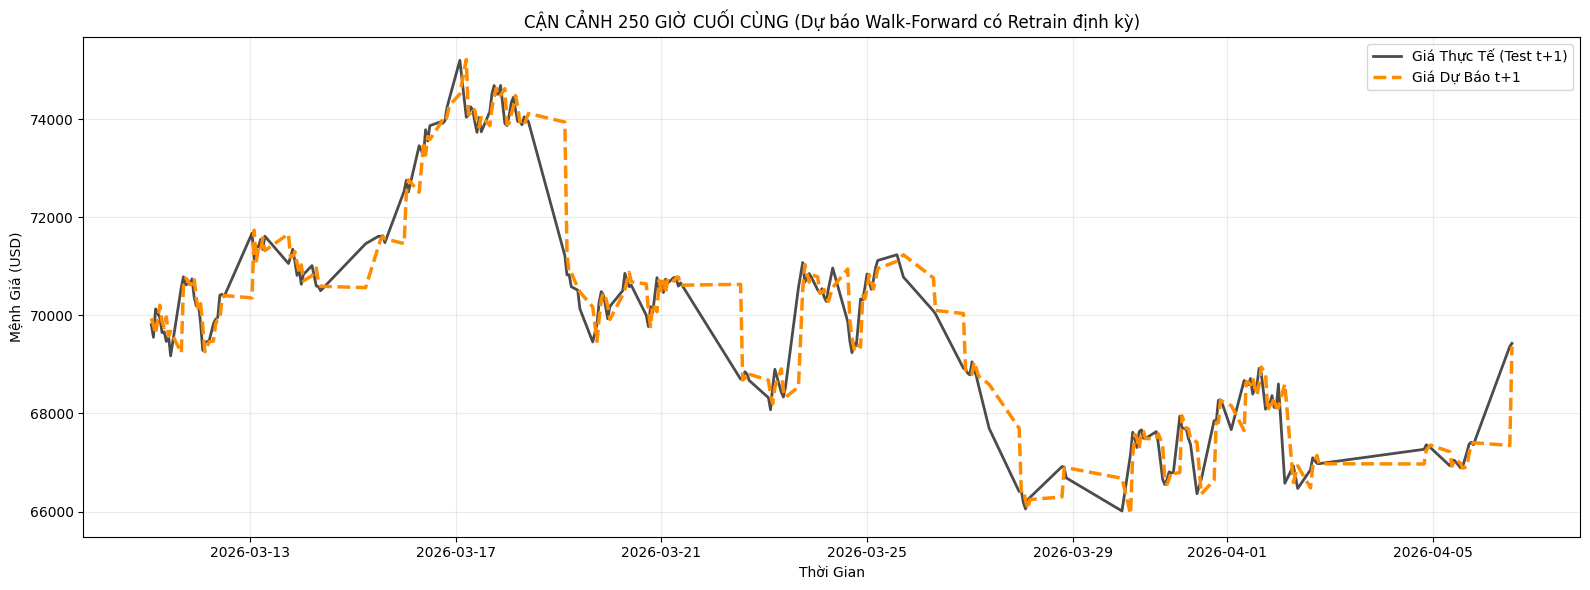

In [31]:
# 5. DỰ BÁO NHỮNG ĐIỂM TEST, ĐO LƯỜNG VÀ KIỂM ĐỊNH (✅ SỬ DỤNG WALK-FORWARD + LOG RETURNS + DYNAMIC RETRAINING)
print("--- KHỞI ĐỘNG WALK-FORWARD VALIDATION TRÊN TEST SET --- \n")

predictions_price = []
actuals_price = []
pred_log_returns = []
actual_log_returns = []
pred_dates = []

# Tần suất huấn luyện lại (Retrain Frequency)
retrain_freq = 168 

# Chạy vòng lặp qua từng Index của tập Test
test_index = X_test.index

for t, current_time in enumerate(test_index):
    
    # --- BƯỚC 1: DYNAMIC RETRAINING VỚI CÚ PHÁP REBUILD FEATURE NATIVE ---
    if t > 0 and t % retrain_freq == 0:
        print(f"Cập nhật mô hình tại {current_time} (Trượt cửa sổ học - {window_size} nến)...")
        current_df_retrain = df.loc[:current_time]
        current_train_features = create_features(current_df_retrain, is_train=True)
        
        start_idx = max(0, len(current_train_features) - window_size)
        current_train_df = current_train_features.iloc[start_idx:]
        
        val_size_new = int(len(current_train_df) * 0.1)
        train_new_df = current_train_df.iloc[:-val_size_new]
        val_new_df = current_train_df.iloc[-val_size_new:]
        
        X_train_new = train_new_df.drop(drop_cols, axis=1)
        y_train_new = train_new_df['target_log_return']
        X_val_new = val_new_df.drop(drop_cols, axis=1)
        y_val_new = val_new_df['target_log_return']
        
        xgb_model.fit(X_train_new, y_train_new, eval_set=[(X_val_new, y_val_new)], verbose=False)
    
    # --- BƯỚC 2: BUILD FEATURE CHO BƯỚC HIỆN TẠI (STRICT WALK-FORWARD PREDICTION) ---
    df_slice = df.loc[:current_time].iloc[-500:]
    feat_slice = create_features(df_slice, is_train=False)
    
    X_step = feat_slice.drop(drop_cols, axis=1).iloc[[-1]]
    
    # Dự báo Target Log Return cho t+1
    pred_log_ret = xgb_model.predict(X_step)[0]
    
    # Lấy Giá THẬT TẠI t và Inverse ra Giá dự báo t+1 (Không tích lũy sai số / No Drift)
    price_t = feat_slice['price'].iloc[-1]
    pred_price_t_plus_1 = price_t * np.exp(pred_log_ret)
    
    # --- SO SÁNH / GHI NHẬN KẾT QUẢ ---
    idx_pos = df.index.get_loc(current_time)
    if idx_pos + 1 < len(df):
        true_price_t_plus_1 = df['price'].iloc[idx_pos + 1]
        true_log_ret_t_plus_1 = df['log_return'].iloc[idx_pos + 1] # Target thật
        date_t_plus_1 = df.index[idx_pos + 1]
        
        predictions_price.append(pred_price_t_plus_1)
        actuals_price.append(true_price_t_plus_1)
        
        pred_log_returns.append(pred_log_ret)
        actual_log_returns.append(true_log_ret_t_plus_1)
        
        pred_dates.append(date_t_plus_1)
        
    if (t+1) % 500 == 0:
        print(f"  Đã trượt và dự báo {t+1}/{len(test_index)} bước...")

# Metric Computation
predictions_price = np.array(predictions_price)
actuals_price = np.array(actuals_price)
pred_log_returns = np.array(pred_log_returns)
actual_log_returns = np.array(actual_log_returns)
pred_dates = pd.to_datetime(pred_dates)

# DIRECT EVALUATION ON RETURNS (Không bị mask bởi giá)
rmse_return = np.sqrt(mean_squared_error(actual_log_returns, pred_log_returns))
mae_return = mean_absolute_error(actual_log_returns, pred_log_returns)

# DIRECTIONAL ACCURACY (Signal định hướng: Lên/Xuống có chuẩn?)
true_direction = np.sign(actual_log_returns)
pred_direction = np.sign(pred_log_returns)
directional_accuracy = np.mean(true_direction == pred_direction) * 100

print(f"\nXGBoost WALK-FORWARD PIPELINE CHUẨN (INSTITUTIONAL):")
print(f"🔹 DIRECT RETURN METRICS (True Signal Accuracy):")
print(f"   RMSE (Return): {rmse_return:.6f}")
print(f"   MAE  (Return): {mae_return:.6f}")
print(f"   Directional Accuracy (Hit Rate): {directional_accuracy:.2f}%")

rmse = np.sqrt(mean_squared_error(actuals_price, predictions_price))
mae = mean_absolute_error(actuals_price, predictions_price)
print(f"\n🔹 PRICE METRICS (From Base t):")
print(f"   RMSE (Price): ${rmse:,.2f}")
print(f"   MAE  (Price): ${mae:,.2f}\n")

# ========= Plot Bảng Biểu Cận Cảnh (Zoom) ============
plt.figure(figsize=(16, 6))

zoom_dates = pred_dates[-250:]
zoom_actuals = actuals_price[-250:]
zoom_preds = predictions_price[-250:]

plt.plot(zoom_dates, zoom_actuals, label='Giá Thực Tế (Test t+1)', color='black', alpha=0.7, lw=2)
plt.plot(zoom_dates, zoom_preds,   label='Giá Dự Báo t+1', color='darkorange', linestyle='--', lw=2.5)

plt.title('CẬN CẢNH 250 GIỜ CUỐI CÙNG (Dự báo Walk-Forward có Retrain định kỳ)')
plt.xlabel('Thời Gian')
plt.ylabel('Mệnh Giá (USD)')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
import joblib
import os
import xgboost as xgb

# Lưu đúng vào thư mục Models nằm cùng cấp với notebook hiện tại
models_dir = os.path.abspath('Models')
os.makedirs(models_dir, exist_ok=True)

pkl_main_path = os.path.join(models_dir, 'xgboost_btc_model.pkl')
pkl_alias_path = os.path.join(models_dir, 'xgboost.pkl')
json_path = os.path.join(models_dir, 'xgboost_btc_model.json')
buffer_path = os.path.join(models_dir, 'live_buffer_data.csv')

# 1) Lưu model theo pickle (2 tên để dễ tìm)
joblib.dump(xgb_model, pkl_main_path)
joblib.dump(xgb_model, pkl_alias_path)

# 2) Lưu model theo định dạng native XGBoost (an toàn hơn khi khác version)
xgb_model.get_booster().save_model(json_path)

# 3) Lưu buffer phục vụ app
df.tail(500).to_csv(buffer_path)

print('✅ Đã xuất model và buffer thành công!')
print(f'PKL chính : {pkl_main_path}')
print(f'PKL alias : {pkl_alias_path}')
print(f'JSON model: {json_path}')
print(f'Buffer    : {buffer_path}')

✅ Đã xuất model và buffer thành công!
PKL chính : d:\DataMining\sgu-2026-datamining-timeseries\src\time-series\Models\xgboost_btc_model.pkl
PKL alias : d:\DataMining\sgu-2026-datamining-timeseries\src\time-series\Models\xgboost.pkl
JSON model: d:\DataMining\sgu-2026-datamining-timeseries\src\time-series\Models\xgboost_btc_model.json
Buffer    : d:\DataMining\sgu-2026-datamining-timeseries\src\time-series\Models\live_buffer_data.csv
